In [27]:
import demes
import msprime
import tszip
import tskit
import numpy as np
import pandas as pd
import yaml
import demesdraw
import sys
import matplotlib.pyplot as plt
sys.path.append("../")
import yaml
from pathlib import Path
import matplotlib
from mycolorpy import colorlist as mcp
import scipy.stats as stats
import seaborn as sns
from matplotlib.gridspec import GridSpec
from utils import *
import pandas as pd
import polars as pl
import pybedtools
import warnings
from tqdm import tqdm 

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fig1C-D

/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/mycolorpy/colorlist.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c_map = plt.cm.get_cmap(str(cmap)) # select the desired cmap
/scratch16/rmccoy22/abiddan1/trace_paper/utils.py:32: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/scratch16/rmccoy22/abiddan1/trace_paper/utils.py:32: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/scratch16/rmccoy22/abiddan1/trace_paper/utils.py:32: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/scratch16/rmccoy22/abiddan1/trace_paper/utils.py:32: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/scratch16/rmccoy22/abiddan1/trace_paper/utils.py:32: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/scratch16/rmccoy22/abiddan1/trace_paper/uti

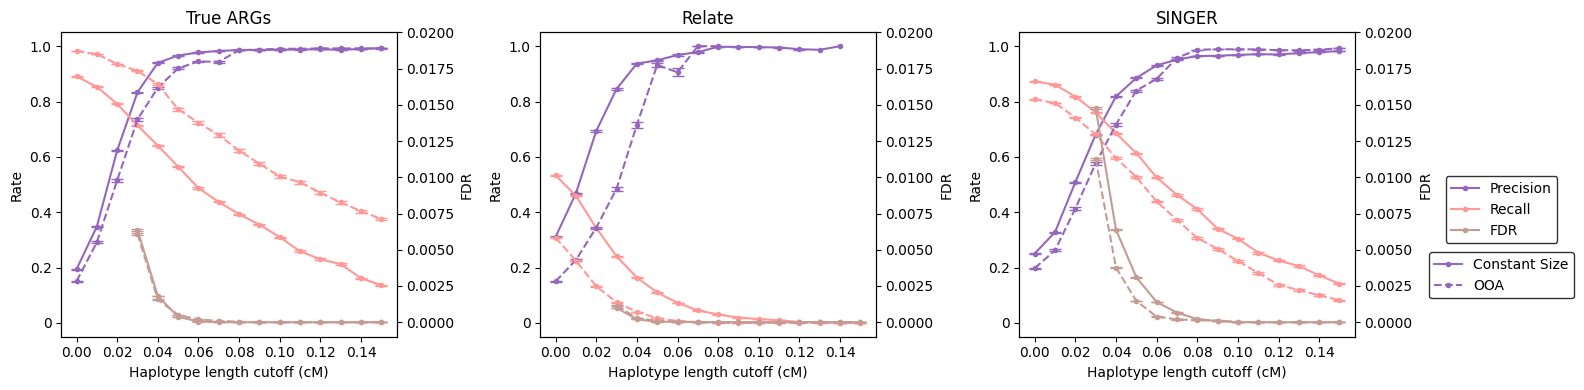

In [6]:
warnings.filterwarnings(action='once')

pp_cutoff=0.90
l_cutoff = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15]
seeds = range(1, 11)
colors=mcp.gen_color(cmap="tab20",n=20)
n = 100
intro = 0.02
cll = [colors[2], colors[4], colors[12], colors[8], colors[7]]
t = 15000
fig, ax = plt.subplots(1, 3, figsize=(16,4), sharey = 'all', sharex = 'all')
linestyles = ['-', '--', ':', '-.']
inference = ['msprime', 'relate', 'singer']
versions = ['m2_ori', 'm2_ori']
models = ['split_constant', 'ooa_neanderthal5r19_simp']
deme_label = ['Constant Size', 'OOA', 'Gene flow after OOA', 'Introgression before OOA']
for ii, f in enumerate(inference):
    ax2 = ax[ii].twinx()
    ax2.set_ylabel('FDR')
    ax2.set_ylim([-0.001, 0.02])
    for j in range(len(versions)):
        fpath = 'trace_zenodo/for_plotting/results/simulation_benchmark/arg_infer/'+str(models[j])+'/' + str(versions[j]) + '/' + str(f) + '/n' + str(n) + '_seed'
        t_archaic = str(intro)
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
        precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        ax[ii].errorbar(l_cutoff, precision, yerr=precision_err,marker='o',markersize=3, color=colors[8],capsize=4, fmt = linestyles[j], label=f"{deme_label[j]}")
        ax[ii].errorbar(l_cutoff, recall, yerr=recall_err,marker='o',markersize=3, color=colors[7],capsize=4, fmt = linestyles[j])
        ax2.errorbar(l_cutoff[3:], false_discovery[3:] * 2 / 100, yerr=false_discovery_err[3:] * 2 / 100,marker='o',markersize=3, color=colors[11],capsize=4, fmt = linestyles[j])
    s = ax2.get_lines()
lines = ax[2].get_lines()
legend1 = ax[2].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.25, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[2].legend([lines[i] for i in [0,6]], deme_label, bbox_to_anchor=(1.2, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[2].add_artist(legend1)

# ax[0].axvline(x=0.05, color='red', linestyle='--', linewidth=1)
# ax[1].axvline(x=0.05, color='red', linestyle='--', linewidth=1)
# ax[2].axvline(x=0.05, color='red', linestyle='--', linewidth=1)
ax[0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[2].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[0].yaxis.set_tick_params(labelleft=True)
ax[1].yaxis.set_tick_params(labelleft=True)
ax[2].yaxis.set_tick_params(labelleft=True)
ax[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
ax[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
ax[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
ax[0].set_ylabel('Rate')
ax[1].set_ylabel('Rate')
ax[2].set_ylabel('Rate')
ax[0].set_xlabel('Haplotype length cutoff (cM)')
ax[1].set_xlabel('Haplotype length cutoff (cM)')
ax[2].set_xlabel('Haplotype length cutoff (cM)')
ax[0].set_title('True ARGs')
ax[1].set_title('Relate')
ax[2].set_title('SINGER')
plt.tight_layout()

# Fig2A & Fig4A

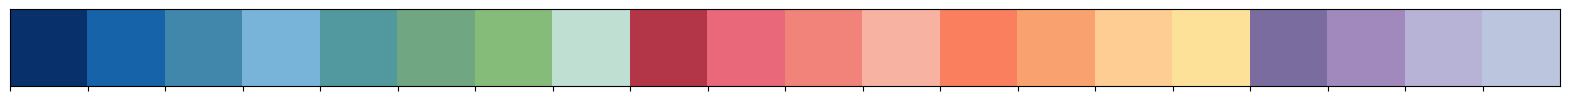

In [7]:
cls = ["#08306B", "#1663AA", "#4187AC", "#78B4D9", "#51999F", "#71A682", "#86BC79", "#BFDFD2", "#B23648", "#E9687A", "#F1837A", "#F8B2A2", "#F97F5F", "#FAA26F", "#FDCD94", "#FEE199", "#7B6C9F", "#A188BD", "#B6B3D6", "#BBC5DE"]
custom_palette = sns.color_palette(cls)
sns.palplot(custom_palette)

In [9]:
chrlen = 2164834110 # total length of autosomes in hg38 strict mask
df = pd.read_csv('trace_zenodo/data/sample_info/treeID_EUR.txt',sep='\t')
data = pd.read_csv("trace_zenodo/data/tables/trace_t15000_eur.csv")
data = data[(data['nderived_strict'] >= 30) & (data[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis=1) >= 10)]
data = data[["chromosome", "start", "end", "length(bp)", "ID", "assign_label"]]
data = df[df["SuperGroup"]=="EUR"].merge(data, on='ID', how='left')
inds = data['ID'].unique()
singer_inds = data.groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen
singer_nea = data[data['assign_label'] == "NEA"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen
singer_den = data[data['assign_label'] == "DEN"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen
singer_ghost = data[data['assign_label'] == "Ghost"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen
populations = ['EUR'] * len(inds)
populations2 = ['GBR'] * len(inds)

df = pd.read_csv('trace_zenodo/data/sample_info/treeID_eAFR.txt',sep='\t')
data = pd.read_csv("trace_zenodo/data/tables/trace_t15000_eafr.csv")
data = data[["chromosome", "start", "end", "length(bp)", "ID", "assign_label"]]
data = df[df["Population"]=="LWK"].merge(data, on='ID', how='left')
inds = data['ID'].unique()
singer_inds = np.concatenate([singer_inds, data.groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_nea = np.concatenate([singer_nea, data[data['assign_label'] == "NEA"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_den = np.concatenate([singer_den, data[data['assign_label'] == "DEN"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_ghost = np.concatenate([singer_ghost, data[data['assign_label'] == "Ghost"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
populations = populations + ['AFR'] * len(inds)
populations2 = populations2 + ['LWK'] * len(inds)

df = pd.read_csv('trace_zenodo/data/sample_info/treeID_wAFR.txt',sep='\t')
data = pd.read_csv("trace_zenodo/data/tables/trace_t15000_wafr.csv")
data = data[["chromosome", "start", "end", "length(bp)", "ID", "assign_label"]]
data = df[df["Population"]=="YRI"].merge(data, on='ID', how='left')
inds = data['ID'].unique()
singer_inds = np.concatenate([singer_inds, data.groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_nea = np.concatenate([singer_nea, data[data['assign_label'] == "NEA"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_den = np.concatenate([singer_den, data[data['assign_label'] == "DEN"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_ghost = np.concatenate([singer_ghost, data[data['assign_label'] == "Ghost"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
populations = populations + ['AFR'] * len(inds)
populations2 = populations2 + ['YRI'] * len(inds)

df = pd.read_csv('trace_zenodo/data/sample_info/treeID_EAS.txt',sep='\t')
data = pd.read_csv("trace_zenodo/data/tables/trace_t15000_eas.csv")
data = data[(data['nderived_strict'] >= 30) & (data[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis=1) >= 10)]
data = data[["chromosome", "start", "end", "length(bp)", "ID", "assign_label"]]
data = df[df["SuperGroup"]=="EAS"].merge(data, on='ID', how='left')
inds = data['ID'].unique()
singer_inds = np.concatenate([singer_inds, data.groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_nea = np.concatenate([singer_nea, data[data['assign_label'] == "NEA"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_den = np.concatenate([singer_den, data[data['assign_label'] == "DEN"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_ghost = np.concatenate([singer_ghost, data[data['assign_label'] == "Ghost"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
populations = populations + ['EAS'] * len(inds)
populations2 = populations2 + ['CHB'] * len(inds)

df = pd.read_csv('trace_zenodo/data/sample_info/treeID_SAS.txt',sep='\t')
data = pd.read_csv("trace_zenodo/data/tables/trace_t15000_sas.csv")
data = data[(data['nderived_strict'] >= 30) & (data[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis=1) >= 10)]
data = data[["chromosome", "start", "end", "length(bp)", "ID", "assign_label"]]
data = df[df["SuperGroup"]=="SAS"].merge(data, on='ID', how='left')
inds = data['ID'].unique()
singer_inds = np.concatenate([singer_inds, data.groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_nea = np.concatenate([singer_nea, data[data['assign_label'] == "NEA"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_den = np.concatenate([singer_den, data[data['assign_label'] == "DEN"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_ghost = np.concatenate([singer_ghost, data[data['assign_label'] == "Ghost"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
populations = populations + ['SAS'] * len(inds)
populations2 = populations2 + ['ITU'] * len(inds)

df = pd.read_csv('trace_zenodo/data/sample_info/treeID_OCN.txt',sep='\t')
data = pd.read_csv("trace_zenodo/data/tables/trace_t15000_ocn.csv")
data = data[(data['nderived_strict'] >= 30) & (data[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis=1) >= 10)]
data.loc[(data['nd10_prop'] > 0.2) & (data['nd10_b'] > data['nd01_b']), 'assign_label'] = 'NEA'
data.loc[(data['nd10_prop'] > 0.2) & (data['nd10_b'] < data['nd01_b']), 'assign_label'] = 'DEN'
data.loc[data['nd00_prop'] > 0.8, 'assign_label'] = 'Ghost'
data = data[["chromosome", "start", "end", "length(bp)", "ID", "assign_label"]]
data = df[df["SuperGroup"]=="OCN"].merge(data, on='ID', how='left')
inds = data['ID'].unique()
singer_inds = np.concatenate([singer_inds, data.groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_nea = np.concatenate([singer_nea, data[data['assign_label'] == "NEA"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_den = np.concatenate([singer_den, data[data['assign_label'] == "DEN"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
singer_ghost = np.concatenate([singer_ghost, data[data['assign_label'] == "Ghost"].groupby('ID')["length(bp)"].sum().reindex(data['ID'].unique()).fillna(0) / chrlen])
populations = populations + ['OCN'] * len(inds)
populations2 = populations2 + ['OCN'] * len(inds)

data1_dict = {
    'Data': list(singer_inds) + list(singer_nea) + list(singer_den) + list(singer_ghost),
    'SuperGroup': populations * 4,
    'Population': populations2 * 4,
    'Method': ['TRACE'] * len(singer_inds) + ['TRACE Neanderthal'] * len(singer_nea) + ['TRACE Denisovan'] * len(singer_den) + ['TRACE Ghost'] * len(singer_ghost),
    'Label':["TRACE"] * len(singer_inds) + ["TRACE_N"] * len(singer_nea) + ["TRACE_D"] * len(singer_den) + ["TRACE_G"] * len(singer_ghost)
}
d1 = pd.DataFrame(data1_dict)
d1["Data"] = d1["Data"] * 100

/tmp/ipykernel_3873006/1313760786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2["Archaic"] = d2["Method"].apply(lambda x: x.split(" ")[1])
/tmp/ipykernel_3873006/1313760786.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2["Pop"] = "None"
/tmp/ipykernel_3873006/1313760786.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


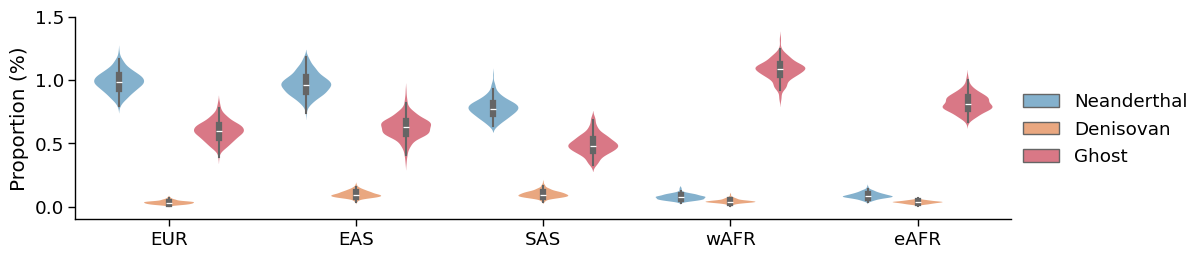

In [11]:
warnings.filterwarnings(action='once')
d2 = d1[(d1["Method"] == "TRACE Neanderthal") | (d1["Method"] == "TRACE Denisovan") | (d1["Method"] == "TRACE Ghost")]
d2["Archaic"] = d2["Method"].apply(lambda x: x.split(" ")[1])
d2["Pop"] = "None"
d2.loc[d2["Population"]=="YRI", "Pop"] = "wAFR"
d2.loc[d2["Population"]=="LWK", "Pop"] = "eAFR"
d2.loc[d2["SuperGroup"]=="EUR", "Pop"] = "EUR"
d2.loc[d2["SuperGroup"]=="EAS", "Pop"] = "EAS"
d2.loc[d2["SuperGroup"]=="SAS", "Pop"] = "SAS"
d2.loc[d2["SuperGroup"]=="OCN", "Pop"] = "OCN"
sns.set_context("paper", font_scale=1.5)
g = sns.catplot(
    data=d2[~d2["Population"].isin(["OCN"])],
    x="Pop", 
    y="Data", 
    hue="Archaic", 
    order=["EUR", "EAS", "SAS", "wAFR", "eAFR"],
    palette=[cls[3], cls[13], cls[9]],
    kind="violin",
    scale='width',
    height=3,
    aspect=3.5,
)
for ax in g.axes.flat:
    for collection in ax.collections:
        collection.set_edgecolor('none')
g._legend.set_title(None)
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("Proportion (%)")
    ax.set_ylim([-0.1, 1.5])
# plt.savefig('images/fig2a.pdf', bbox_inches='tight')

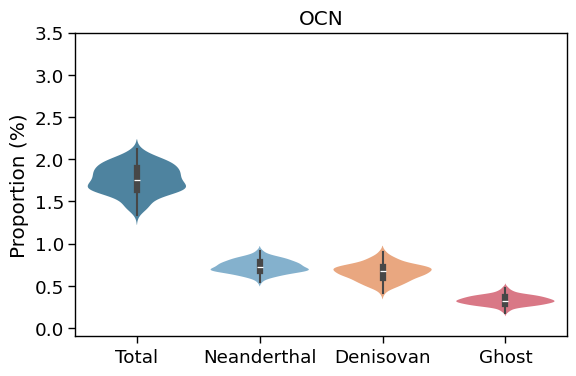

In [12]:
d1_ocn = {
            "TRACE": d1[(d1["SuperGroup"] == "OCN") & (d1["Method"] == "TRACE")]["Data"].to_list(),
            "TRACE_N": d1[(d1["SuperGroup"] == "OCN") & (d1["Method"] == "TRACE Neanderthal")]["Data"].to_list(),
            "TRACE_D": d1[(d1["SuperGroup"] == "OCN") & (d1["Method"] == "TRACE Denisovan")]["Data"].to_list(),
            "TRACE_G": d1[(d1["SuperGroup"] == "OCN") & (d1["Method"] == "TRACE Ghost")]["Data"].to_list()}
d1_ocn = pd.DataFrame(d1_ocn)

fig, ax = plt.subplots(1, 1, figsize=(6, 4));
sns.violinplot(data=d1_ocn, order = ["TRACE", "TRACE_N", "TRACE_D", "TRACE_G"], palette = [cls[2], cls[3], cls[13], cls[9]], ax=ax);
for i, artist in enumerate(ax.collections):
    artist.set_edgecolor(None)
ax.set_ylabel('Proportion (%)');

ax.set_xlabel('');

ax.set_title('OCN');

ax.set_ylim([-0.1, 3.5])
ax.set_xticks([0, 1, 2, 3], ["Total", "Neanderthal", "Denisovan", "Ghost"])

fig.tight_layout()
# plt.savefig('images/fig4a.pdf', bbox_inches='tight')


# Fig 2C

In [13]:
df = pd.read_csv('trace_zenodo/data/tables/trace_t15000_wafr.csv')
df = df.drop_duplicates(['chromosome','start','end'], keep='last')
df = df[(df["nderived_strict"] > 30) & (df[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis = 1) > 10) & (df["tot_b"] > 10)]
df["nea_aff"] = (df["ND10_strict"] + df["ND11_strict"]) / (df[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis = 1))
df["den_aff"] = (df["ND01_strict"] + df["ND11_strict"]) / (df[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis = 1))

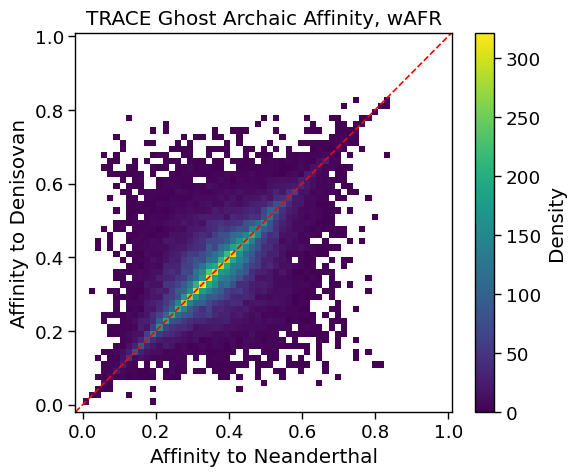

In [14]:
dff_nea = df[df["assign_label"] == "NEA"]
dff_den = df[df["assign_label"] == "DEN"]
dff_ghost = df[df["assign_label"] == "Ghost"]
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.histplot(x=dff_ghost['nea_aff'], y=dff_ghost['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax)
ax.axline((0, 0), slope=1, color='red', linestyle='--')
ax.set_xlabel('Affinity to Neanderthal')
ax.set_ylabel('Affinity to Denisovan')
ax.set_title('TRACE Ghost Archaic Affinity, wAFR')
ax.set_ylim([-0.02, 1.01])
ax.set_xlim([-0.02, 1.01])
plt.tight_layout()
# plt.savefig('images/figS4_3def.pdf', bbox_inches='tight')

# Fig2B

In [16]:
pops = ['eafr', 'wafr', 'eur', 'eas', 'sas']
for pop in pops:
    data = pd.read_csv(f"trace_zenodo/data/tables/trace_t15000_{pop}.csv")
    data['start'] = (data['start'] / 1e3).astype(int)
    data['end'] = (data['end'] / 1e3).astype(int)
    for i in tqdm(range(1, 23)):
        nea = np.zeros((data['ID'].nunique(),250000))
        den = np.zeros((data['ID'].nunique(),250000))
        ghost = np.zeros((data['ID'].nunique(),250000))
        subdata = data[data["chromosome"] == f"chr{i}"]
        minID = subdata["ID"].min()
        for _, j in subdata.iterrows():
            if j["assign_label"] == "NEA":
                nea[j["ID"] - minID, j["start"]:j["end"]] = 1
            elif j["assign_label"] == "DEN":
                den[j["ID"] - minID, j["start"]:j["end"]] = 1
            elif j["assign_label"] == "Ghost":
                ghost[j["ID"] - minID, j["start"]:j["end"]] = 1
        np.savez(f"trace_zenodo/for_plotting/trace_t15000_{pop}_chr{i}.npz", nea=nea, den=den, ghost=ghost)

100%|██████████████████████████████████████████████████████████████████████████| 22/22 [00:41<00:00,  1.89s/it]


In [18]:
chrlen = 2164834110
df = {"ID":[], "SuperGroup":[], "Population":[], "Ghost":[], "Ghost_shared":[], "Neanderthal":[], "Neanderthal_shared":[], "Denisovan":[], "Denisovan_shared":[]}
popcode = {"wAFR":0, "eAFR":1, "EUR":2, "EAS":3, "SAS":4, "nonAFR":5, "OCN":6}
for i in tqdm(range(1, 23)):
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_wafr_chr{i}.npz")
    afr1_states = data['nea']
    afr1_popshared = afr1_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eafr_chr{i}.npz")
    afr2_states = data['nea']
    afr2_popshared = afr2_states.max(axis = 0)
    afr_states = np.vstack([afr1_states, afr2_states])
    afr_popshared = afr_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eur_chr{i}.npz")
    eur_states = data['nea']
    eur_popshared = eur_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eas_chr{i}.npz")
    eas_states = data['nea']
    eas_popshared = eas_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_sas_chr{i}.npz")
    sas_states = data['nea']
    sas_popshared = sas_states.max(axis = 0)
    nonafr_states = np.vstack([eur_states, eas_states, sas_states])
    nonafr_shared = np.vstack([eur_popshared, eas_popshared, sas_popshared]).max(axis=0)
    if i == 1:
        df["ID"] = df["ID"] + list(range(afr_states.shape[0])) + list(range(eur_states.shape[0])) + list(range(eas_states.shape[0])) + list(range(sas_states.shape[0])) + list(range(nonafr_states.shape[0]))
        df["Population"] = df["Population"] + ['YRI'] * afr1_states.shape[0] + ['LWK'] * afr2_states.shape[0] + ['GBR'] * eur_states.shape[0] + ['CHB'] * eas_states.shape[0] + ['ITU'] * sas_states.shape[0] + ['nonAFR'] * (nonafr_states.shape[0])
        df["SuperGroup"] = df["SuperGroup"] + ['wAFR'] * afr1_states.shape[0] + ['eAFR'] * afr2_states.shape[0] + ['EUR'] * eur_states.shape[0] + ['EAS'] * eas_states.shape[0] + ['SAS'] * sas_states.shape[0] + ['nonAFR'] * (nonafr_states.shape[0])
        df["Neanderthal"] = np.zeros(afr_states.shape[0] + eur_states.shape[0] + eas_states.shape[0] + sas_states.shape[0] + nonafr_states.shape[0])
        df["Neanderthal_shared"] = np.zeros(afr_states.shape[0] + eur_states.shape[0] + eas_states.shape[0] + sas_states.shape[0] + nonafr_states.shape[0])
        df["Denisovan"] = np.zeros(afr_states.shape[0] + eur_states.shape[0] + eas_states.shape[0] + sas_states.shape[0] + nonafr_states.shape[0])
        df["Denisovan_shared"] = np.zeros(afr_states.shape[0] + eur_states.shape[0] + eas_states.shape[0] + sas_states.shape[0] + nonafr_states.shape[0])
        df["Ghost"] = np.zeros(afr_states.shape[0] + eur_states.shape[0] + eas_states.shape[0] + sas_states.shape[0] + nonafr_states.shape[0])
        df["Ghost_shared"] = np.zeros(afr_states.shape[0] + eur_states.shape[0] + eas_states.shape[0] + sas_states.shape[0] + nonafr_states.shape[0])
    df["Neanderthal"] = df["Neanderthal"] + np.concatenate([afr1_states.sum(axis=1), afr2_states.sum(axis=1),eur_states.sum(axis=1), eas_states.sum(axis=1), sas_states.sum(axis=1), nonafr_states.sum(axis=1)])
    df["Neanderthal_shared"] = df["Neanderthal_shared"] + np.concatenate([afr1_states[:, nonafr_shared > 0].sum(axis=1), afr2_states[:, nonafr_shared > 0].sum(axis=1), eur_states[:, afr1_popshared > 0].sum(axis=1), eas_states[:, afr1_popshared > 0].sum(axis=1), sas_states[:, afr1_popshared > 0].sum(axis=1), nonafr_states[:, afr1_popshared > 0].sum(axis=1)])

    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_wafr_chr{i}.npz")
    afr1_states = data['den']
    afr1_popshared = afr1_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eafr_chr{i}.npz")
    afr2_states = data['den']
    afr2_popshared = afr2_states.max(axis = 0)
    afr_states = np.vstack([afr1_states, afr2_states])
    afr_popshared = afr_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eur_chr{i}.npz")
    eur_states = data['den']
    eur_popshared = eur_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eas_chr{i}.npz")
    eas_states = data['den']
    eas_popshared = eas_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_sas_chr{i}.npz")
    sas_states = data['den']
    sas_popshared = sas_states.max(axis = 0)
    nonafr_states = np.vstack([eur_states, eas_states, sas_states])
    nonafr_shared = np.vstack([eur_popshared, eas_popshared, sas_popshared]).max(axis=0)
    df["Denisovan"] = df["Denisovan"] + np.concatenate([afr1_states.sum(axis=1), afr2_states.sum(axis=1),eur_states.sum(axis=1), eas_states.sum(axis=1), sas_states.sum(axis=1), nonafr_states.sum(axis=1)])
    df["Denisovan_shared"] = df["Denisovan_shared"] + np.concatenate([afr1_states[:, nonafr_shared > 0].sum(axis=1), afr2_states[:, nonafr_shared > 0].sum(axis=1), eur_states[:, afr1_popshared > 0].sum(axis=1), eas_states[:, afr1_popshared > 0].sum(axis=1), sas_states[:, afr1_popshared > 0].sum(axis=1), nonafr_states[:, afr1_popshared > 0].sum(axis=1)])

    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_wafr_chr{i}.npz")
    afr1_states = data['ghost']
    afr1_popshared = afr1_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eafr_chr{i}.npz")
    afr2_states = data['ghost']
    afr2_popshared = afr2_states.max(axis = 0)
    afr_states = np.vstack([afr1_states, afr2_states])
    afr_popshared = afr_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eur_chr{i}.npz")
    eur_states = data['ghost']
    eur_popshared = eur_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_eas_chr{i}.npz")
    eas_states = data['ghost']
    eas_popshared = eas_states.max(axis = 0)
    data = np.load(f"trace_zenodo/for_plotting/trace_t15000_sas_chr{i}.npz")
    sas_states = data['ghost']
    sas_popshared = sas_states.max(axis = 0)
    nonafr_states = np.vstack([eur_states, eas_states, sas_states])
    nonafr_shared = np.vstack([eur_popshared, eas_popshared, sas_popshared]).max(axis=0)
    df["Ghost"] = df["Ghost"] + np.concatenate([afr1_states.sum(axis=1), afr2_states.sum(axis=1),eur_states.sum(axis=1), eas_states.sum(axis=1), sas_states.sum(axis=1), nonafr_states.sum(axis=1)])
    df["Ghost_shared"] = df["Ghost_shared"] + np.concatenate([afr1_states[:, nonafr_shared > 0].sum(axis=1), afr2_states[:, nonafr_shared > 0].sum(axis=1), eur_states[:, afr1_popshared > 0].sum(axis=1), eas_states[:, afr1_popshared > 0].sum(axis=1), sas_states[:, afr1_popshared > 0].sum(axis=1), nonafr_states[:, afr1_popshared > 0].sum(axis=1)])

df["Neanderthal"] = np.array(df["Neanderthal"]) * 100000 / chrlen
df["Neanderthal_shared"] = np.array(df["Neanderthal_shared"]) * 100000 / chrlen
df["Denisovan"] = np.array(df["Denisovan"]) * 100000 / chrlen
df["Denisovan_shared"] = np.array(df["Denisovan_shared"]) * 100000 / chrlen
df["Ghost"] = np.array(df["Ghost"]) * 100000 / chrlen
df["Ghost_shared"] = np.array(df["Ghost_shared"]) * 100000 / chrlen
df = pd.DataFrame.from_dict(df)
dfa = {}
dfa["Label"] = ["Total"] * (len(df) * 3) + ["Shared"] * (len(df) * 3)
dfa["Population"] = df["Population"].tolist() * 6
dfa["SuperGroup"] = df["SuperGroup"].tolist() * 6
dfa["Data"] = df["Neanderthal"].tolist() + df["Denisovan"].tolist() + df["Ghost"].tolist() + df["Neanderthal_shared"].tolist() + df["Denisovan_shared"].tolist() + df["Ghost_shared"].tolist()
dfa["Archaic"] = (["Neanderthal"] * len(df) + ["Denisovan"] * len(df) + ["Ghost"] * len(df)) * 2
dfa = pd.DataFrame.from_dict(dfa)

100%|██████████████████████████████████████████████████████████████████████████| 22/22 [04:29<00:00, 12.25s/it]


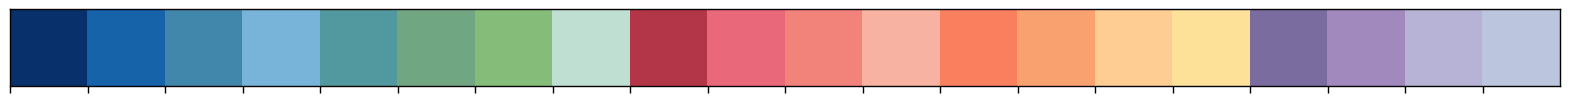

In [19]:
cls = ["#08306B", "#1663AA", "#4187AC", "#78B4D9", "#51999F", "#71A682", "#86BC79", "#BFDFD2", "#B23648", "#E9687A", "#F1837A", "#F8B2A2", "#F97F5F", "#FAA26F", "#FDCD94", "#FEE199", "#7B6C9F", "#A188BD", "#B6B3D6", "#BBC5DE"]
custom_palette = sns.color_palette(cls)
sns.palplot(custom_palette)

/tmp/ipykernel_3873006/1652624864.py:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


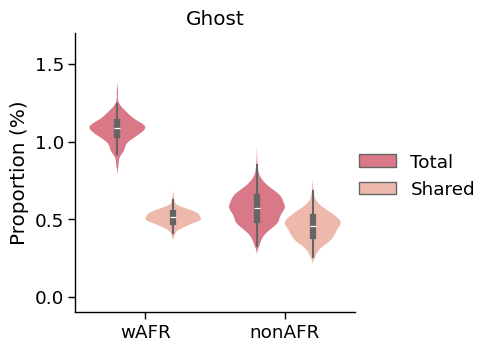

In [20]:
dfa["Pop"] = "None"
dfa.loc[dfa["SuperGroup"]=="wAFR", "Pop"] = "wAFR"
dfa.loc[dfa["SuperGroup"]=="EUR", "Pop"] = "nonAFR"
dfa.loc[dfa["SuperGroup"]=="EAS", "Pop"] = "nonAFR"
dfa.loc[dfa["SuperGroup"]=="SAS", "Pop"] = "nonAFR"
sns.set_context("paper", font_scale=1.5)
g = sns.catplot(
    data=dfa[dfa["Archaic"].isin(["Ghost"]) & (dfa["SuperGroup"].isin(["wAFR", "eAFR", "EUR", "EAS", "SAS"]))], 
    row="Archaic",
    x="Pop", 
    y="Data", 
    hue="Label", 
    hue_order=["Total", "Shared"], 
    palette=[cls[9], cls[11]], 
    order=["wAFR", "nonAFR"],
    kind="violin",
    scale='width',
    height=4,
    aspect=1,
)
for ax in g.axes.flat:
    for collection in ax.collections:
        collection.set_edgecolor('none')
g._legend.set_title(None)
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("Proportion (%)")
    ax.set_ylim([-0.1, 1.7])
g.set_titles("{row_name}")

# Fig 4C

In [21]:
df = pd.read_csv("trace_zenodo/for_plotting/hg38_strictmask.bed", sep='\s+',header=None)
dff = df[df[0].isin([f'chr{i}' for i in range(1,23)])]
total = (dff[2] - dff[1]).sum()
weights = []
for i in range(1, 23):
    dfi = dff[dff[0] != f'chr{i}']
    weights.append((dfi[2] - dfi[1]).sum() / total)

<>:1: DeprecationWarning: invalid escape sequence '\s'


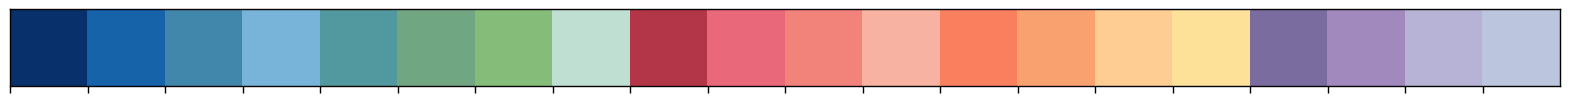

In [22]:
cls = ["#08306B", "#1663AA", "#4187AC", "#78B4D9", "#51999F", "#71A682", "#86BC79", "#BFDFD2", "#B23648", "#E9687A", "#F1837A", "#F8B2A2", "#F97F5F", "#FAA26F", "#FDCD94", "#FEE199", "#7B6C9F", "#A188BD", "#B6B3D6", "#BBC5DE"]
custom_palette = sns.color_palette(cls)
sns.palplot(custom_palette)

/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


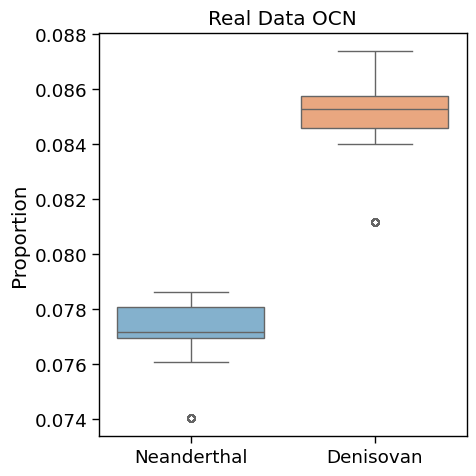

In [23]:
singer_den = []
singer_nea = []
data = pd.read_csv('trace_zenodo/data/tables/trace_t31500_den.csv')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
data2 = pd.read_csv('trace_zenodo/data/tables/trace_t15000_ocn.csv')
data2 = data2[(data2['nderived_strict'] >= 30) & (data2[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis=1) >= 10)]
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="DEN"][["chromosome", "start", "end"]]
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_den.append(np.sum(s) / np.sum(ss))
for s in range(1, 23):
    sdata = data[data["chromosome"] != f"chr{s}"][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != f"chr{s}"]
    subsdata = ssdata[ssdata["assign_label"] == "DEN"][["chromosome", "start", "end"]]
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_den.append(np.sum(s) / np.sum(ss))
data = pd.read_csv('trace_zenodo/for_plotting/trace_t31500_nea.csv')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
data2 = pd.read_csv('trace_zenodo/data/tables/trace_t15000_ocn.csv')
data2 = data2[(data2['nderived_strict'] >= 30) & (data2[["ND00_strict", "ND10_strict", "ND01_strict", "ND11_strict"]].sum(axis=1) >= 10)]
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="NEA"][["chromosome", "start", "end"]]
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_nea.append(np.sum(s) / np.sum(ss))
for s in range(1, 23):
    sdata = data[data["chromosome"] != f"chr{s}"][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != f"chr{s}"]
    subsdata = ssdata[ssdata["assign_label"] == "NEA"][["chromosome", "start", "end"]]
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_nea.append(np.sum(s) / np.sum(ss))

replication_factor = 100  # Choose a large number for smooth representation
replicated_den = []
replicated_nea = []
for i, (theta, weight) in enumerate(zip(singer_den, weights)):
    n_replicates = int(weight * replication_factor)
    replicated_den = replicated_den + [theta] * n_replicates
for i, (theta, weight) in enumerate(zip(singer_nea, weights)):
    n_replicates = int(weight * replication_factor)
    replicated_nea = replicated_nea + [theta] * n_replicates
data_dict = {
    'singer_nea': replicated_nea,
    'singer_den': replicated_den
}
df = pd.DataFrame(data_dict)
order = ['singer_nea', 'singer_den']
plt.figure(figsize=(5, 5));
sns.boxplot(data=df, order=order, palette=[cls[3], cls[13]]);
plt.xticks([0, 1], ['Neanderthal', 'Denisovan'])
plt.ylabel('Proportion');
plt.title('Real Data OCN');
plt.tight_layout()

/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


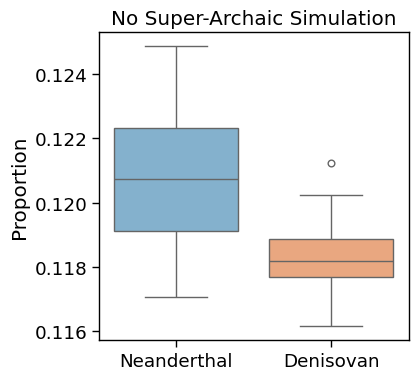

In [24]:
singer_den = []
singer_nea = []
data = pd.read_csv('trace_zenodo/for_plotting/results/nosup_model/singerave_t31500_t15000_den.count_merge.txt',sep='\t')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
data2 = pd.read_csv('trace_zenodo/for_plotting/results/nosup_model/singerave_t15000_ocn.count_merge.txt', sep='\t')
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="DEN"][["chromosome", "start", "end"]].astype(int)
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_den.append(s / ss)
for s in range(1, 11):
    sdata = data[data["chromosome"] != s][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != s]
    subsdata = ssdata[ssdata["assign_label"] == "DEN"][["chromosome", "start", "end"]].astype(int)
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_den.append(s / ss)
data = pd.read_csv('trace_zenodo/for_plotting/results/nosup_model/singerave_t31500_t15000_nea.count_merge.txt',sep='\t')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
data2 = pd.read_csv('trace_zenodo/for_plotting/results/nosup_model/singerave_t15000_ocn.count_merge.txt', sep='\t')
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="NEA"][["chromosome", "start", "end"]].astype(int)
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_nea.append(s / ss)
for s in range(1, 11):
    sdata = data[data["chromosome"] != s][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != s]
    subsdata = ssdata[ssdata["assign_label"] == "NEA"][["chromosome", "start", "end"]].astype(int)
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_nea.append(s / ss)

data_dict = {
    'singer_nea': singer_nea,
    'singer_den': singer_den
}
df = pd.DataFrame(data_dict)
order = ['singer_nea', 'singer_den']
plt.figure(figsize=(4, 4));
sns.boxplot(data=df, order=order, palette=[cls[3], cls[13]]);
plt.xticks([0, 1], ['Neanderthal', 'Denisovan'])
plt.ylabel('Proportion');
plt.title('No Super-Archaic Simulation');

/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/abiddan1/bin/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


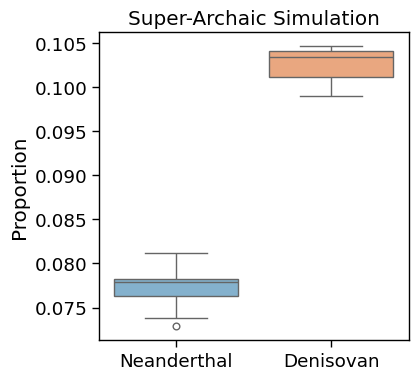

In [25]:
singer_den = []
singer_nea = []
data = pd.read_csv('trace_zenodo/for_plotting/results/super_model/singerave_t31500_t15000_den.count_merge.txt',sep='\t')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
data2 = pd.read_csv('trace_zenodo/for_plotting/results/super_model/singerave_t15000_ocn.count_merge.txt', sep='\t')
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="DEN"][["chromosome", "start", "end"]].astype(int)
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_den.append(s / ss)
for s in range(1, 11):
    sdata = data[data["chromosome"] != s][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != s]
    subsdata = ssdata[ssdata["assign_label"] == "DEN"][["chromosome", "start", "end"]].astype(int)
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_den.append(s / ss)
data = pd.read_csv('trace_zenodo/for_plotting/results/super_model/singerave_t31500_t15000_nea.count_merge.txt',sep='\t')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
data2 = pd.read_csv('trace_zenodo/for_plotting/results/super_model/singerave_t15000_ocn.count_merge.txt', sep='\t')
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="NEA"][["chromosome", "start", "end"]].astype(int)
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_nea.append(s / ss)
for s in range(1, 11):
    sdata = data[data["chromosome"] != s][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != s]
    subsdata = ssdata[ssdata["assign_label"] == "NEA"][["chromosome", "start", "end"]].astype(int)
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_nea.append(s / ss)

data_dict = {
    'singer_nea': singer_nea,
    'singer_den': singer_den
}
df = pd.DataFrame(data_dict)
order = ['singer_nea', 'singer_den']
plt.figure(figsize=(4, 4));
sns.boxplot(data=df, order=order, palette=[cls[3], cls[13]]);
plt.xticks([0, 1], ['Neanderthal', 'Denisovan'])
plt.ylabel('Proportion');
plt.title('Super-Archaic Simulation');

## Fig 3A

In [30]:
# Reading in some data for plotting various tasks
chrom_size_df = pl.read_csv("trace_zenodo/data/metadata/hg38.chrom.sizes", has_header=False, separator="\t")
chrom_size_df.columns = ['chrom', 'size']

deserts_df = pl.read_csv('trace_zenodo/data/metadata/archaic_deserts.tsv', separator=" ")
deserts_df.columns = ['chrom', 'start', 'end', 'type']

centromere_df = pl.read_csv('trace_zenodo/data/metadata/centromeres_grch38.singer_exclude_regions.bed', has_header=False, separator="\t")
centromere_df.columns = ['chrom', 'start', 'end', 'type']
centromere_df.head()

chrom,start,end,type
str,i64,i64,str
"""chr1""",122503247,124785432,"""centromere"""
"""chr1""",122026459,122224535,"""centromere"""
"""chr1""",122224635,122503147,"""centromere"""
"""chr1""",124849229,124932724,"""centromere"""
"""chr1""",124785532,124849129,"""centromere"""


In [42]:
# Reading in all of the peaks for each population
eur_df = pl.read_csv('trace_zenodo/data/peaks/results/enrichments/EUR/bed/*.hg38.peaks.sorted.bed', has_header=False, separator="\t")
eur_df.columns = ['chromosome', 'start', 'end', 'freq','nhap', 'mu', 'sigma', 'autosome_length','assign_label']

sas_df = pl.read_csv('trace_zenodo/data/peaks/results/enrichments/SAS/bed/*.hg38.peaks.sorted.bed', has_header=False, separator="\t")
sas_df.columns = ['chromosome', 'start', 'end', 'freq','nhap', 'mu', 'sigma', 'autosome_length','assign_label']


lwk_df = pl.read_csv('trace_zenodo/data/peaks/results/enrichments/LWK/bed/*.hg38.peaks.sorted.bed', has_header=False, separator="\t")
lwk_df.columns = ['chromosome', 'start', 'end', 'freq','nhap', 'mu', 'sigma', 'autosome_length','assign_label']

yri_df = pl.read_csv('trace_zenodo/data/peaks/results/enrichments/YRI/bed/*.hg38.peaks.sorted.bed', has_header=False, separator="\t")
yri_df.columns = ['chromosome', 'start', 'end', 'freq','nhap', 'mu', 'sigma', 'autosome_length','assign_label']

ocn_df = pl.read_csv('trace_zenodo/data/peaks/results/enrichments/OCN/bed/*.hg38.peaks.sorted.bed', has_header=False, separator="\t")
ocn_df.columns = ['chromosome', 'start', 'end', 'freq','nhap', 'mu', 'sigma', 'autosome_length','assign_label']

eas_df = pl.read_csv('trace_zenodo/data/peaks/results/enrichments/EAS/bed/*.hg38.peaks.sorted.bed', has_header=False, separator="\t")
eas_df.columns = ['chromosome', 'start', 'end', 'freq','nhap', 'mu', 'sigma', 'autosome_length','assign_label']

eur_df = eur_df.with_columns(pl.lit('EUR').alias('Population'))
yri_df = yri_df.with_columns(pl.lit('wAFR').alias('Population'))
lwk_df = lwk_df.with_columns(pl.lit('eAFR').alias('Population'))
ocn_df = ocn_df.with_columns(pl.lit('OCN').alias('Population'))
eas_df = eas_df.with_columns(pl.lit('EAS').alias('Population'))
sas_df = sas_df.with_columns(pl.lit('SAS').alias('Population'))
tot_df = pl.concat([eur_df, yri_df, lwk_df, eas_df, sas_df])
tot_df.head()

chromosome,start,end,freq,nhap,mu,sigma,autosome_length,assign_label,Population
str,i64,i64,f64,i64,f64,f64,i64,str,str
"""chr11""",25796000,25859001,0.137363,182,0.028865,0.05257,2164834110,"""DEN""","""EUR"""
"""chr13""",107908000,107966001,0.181319,182,0.028865,0.05257,2164834110,"""DEN""","""EUR"""
"""chr18""",79351000,79401001,0.159341,182,0.028865,0.05257,2164834110,"""DEN""","""EUR"""
"""chr4""",78376000,78472001,0.269231,182,0.028865,0.05257,2164834110,"""DEN""","""EUR"""
"""chr4""",93616000,93686001,0.142857,182,0.028865,0.05257,2164834110,"""DEN""","""EUR"""


100%|██████████████████████████████████████████████████████████████████████████| 22/22 [00:02<00:00,  8.41it/s]


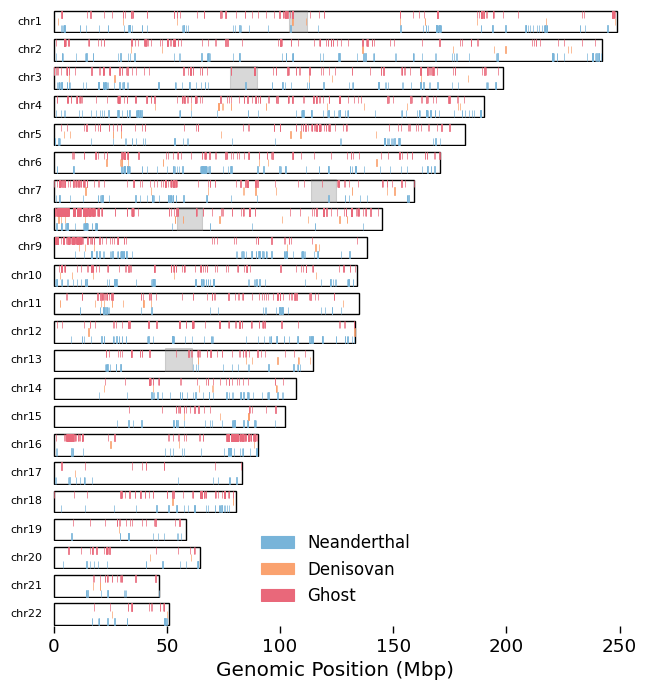

In [48]:
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import to_rgba_array

fig, axs, m = Figure_utils().create_ideogram(chrom_df=chrom_size_df, layout='tight', sharex=True, figsize=(8,8))

axs = Figure_utils().draw_deserts(axs, deserts_df=deserts_df, color='gray', alpha=0.3)
axs = Figure_utils().draw_deserts(axs, deserts_df=centromere_df, category='centromere', color='white', zorder=-10)
axs = Figure_utils().draw_deserts(axs, deserts_df=centromere_df, category='singer', color='white', zorder=-10)
for i in tqdm(range(1,23)):
    axs[i-1].set_ylabel(f'chr{i}', rotation=0, va='center', ha='right', fontsize=8, labelpad=-12)
    nea_segments = tot_df.filter(pl.col('chromosome') == f'chr{i}').filter(pl.col('assign_label') == 'NEA')
    den_segments = tot_df.filter(pl.col('chromosome') == f'chr{i}').filter(pl.col('assign_label') == 'DEN')
    ghost_segments = tot_df.filter(pl.col('chromosome') == f'chr{i}').filter(pl.col('assign_label') == 'Ghost')

    for s,e in zip(nea_segments['start'].to_numpy(), nea_segments['end'].to_numpy()):
        axs[i-1].add_patch(plt.Rectangle((s/1e6, 0), (e-s)/1e6, 1/3-1e-6, lw=0.5, ec=cls[3], fc=cls[3]))
    for s,e in zip(den_segments['start'].to_numpy(), den_segments['end'].to_numpy()):
        axs[i-1].add_patch(plt.Rectangle((s/1e6, 1/3), (e-s)/1e6, 1/3, lw=0.5, ec=cls[13], fc=cls[13]))
    for s,e in zip(ghost_segments['start'].to_numpy(), ghost_segments['end'].to_numpy()):
        # print(s,e)
        axs[i-1].add_patch(plt.Rectangle((s/1e6, 2/3), (e-s)/1e6, 1/3-1e-6, lw=0.5, ec=cls[9], fc=cls[9]))

legend_elements = [Patch(facecolor=cls[3], edgecolor=cls[3],
                         label='Neanderthal'),
                   Patch(facecolor=cls[13], edgecolor=cls[13],
                         label='Denisovan'),
                   Patch(facecolor=cls[9], edgecolor=cls[9],
                         label='Ghost')]

# Create the legend
axs[-2].legend(handles=legend_elements, fontsize=12, 
               bbox_to_anchor=(0.5, 1.2), 
               loc='center', frameon=False).set_zorder(1000)

# Create x-ticks 
axs[-1].set_xticks([0, 50, 100, 150, 200, 250]);
axs[-1].set_xticks([0, 50, 100, 150, 200, 250])
for ax in axs[:-1]:
    [label.set_visible(False) for label in ax.get_xticklabels()]
    ax.tick_params(color='w', grid_color='none')
axs[-1].set_xlabel('Genomic Position (Mbp)');

## Figure S36

In [67]:
pops = ['EAS', 'EUR', 'SAS', 'YRI', 'LWK']
dfs = []
for p in pops:
    cur_df = pl.read_csv(f'trace_zenodo/data/peaks/results/deserts/{p}/bed/*.filt.bed', has_header=False, separator="\t")
    cur_df.columns = ['chrom', "start", "end", "max_freq", "n_haps", "target_pop", "population", "feature", "overlap_bp", "fraction"]
    dfs.append(cur_df)
deserts_filt_mask_df = pl.concat(dfs)
deserts_filt_mask_df = deserts_filt_mask_df.with_columns(pl.col('population').replace('YRI', 'wAFR').replace('LWK', 'eAFR'))
deserts_filt_mask_df = deserts_filt_mask_df.filter(pl.col('population').is_in(['wAFR', 'eAFR', 'EUR', 'EAS', 'SAS']))
deserts_filt_mask_df.head()

chrom,start,end,max_freq,n_haps,target_pop,population,feature,overlap_bp,fraction
str,i64,i64,f64,i64,str,str,str,f64,f64
"""chr1""",57698000,118698000,0.000999,206,"""DEN""","""EAS""","""strict""",8.4602e6,0.846021
"""chr1""",155698000,242698000,0.000896,206,"""DEN""","""EAS""","""strict""",8.3892e6,0.838918
"""chr10""",6498000,37498000,0.000895,206,"""DEN""","""EAS""","""strict""",8.123671e6,0.812367
"""chr10""",48498000,133498000,0.000871,206,"""DEN""","""EAS""","""strict""",8.4192e6,0.841924
"""chr11""",3869000,47869000,0.000685,206,"""DEN""","""EAS""","""strict""",8.5239e6,0.8523855


100%|█████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 146.03it/s]


Text(0.5, 0.91, 'Ghost')

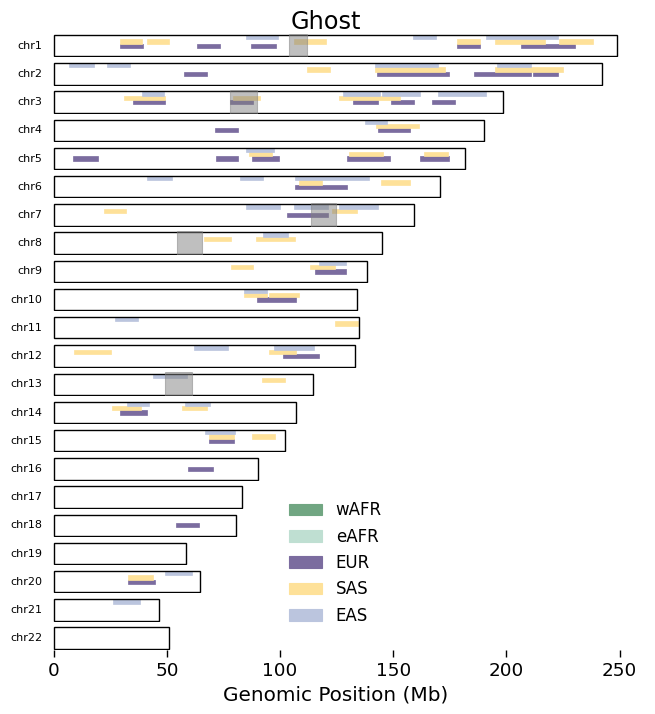

In [71]:
# wAFR: cls[5]
# eafr: cls[7]
# eur: cls[16]
# sas: cls[15]
# eas: cls[19]

color_dict_by_pop = {'EUR': cls[16], 'AFR': cls[6], 'SAS': cls[15], 'EAS': cls[19], 
                     'eAFR': cls[7], 'wAFR': cls[5]}

populations = ['wAFR', 'eAFR', 'EUR', 'SAS', 'EAS']
fig, axs, m = Figure_utils().create_ideogram(chrom_df=chrom_size_df, layout='tight', sharex=True, figsize=(8,8))
axs = Figure_utils().draw_deserts(axs, deserts_df=deserts_df, color='gray', alpha=0.5)
axs = Figure_utils().draw_deserts(axs, deserts_df=centromere_df, category='centromere', color='white', zorder=-10)
axs = Figure_utils().draw_deserts(axs, deserts_df=centromere_df, category='singer', color='white', zorder=-10)
for i in tqdm(range(1,23)):
    axs[i-1].set_ylabel(f'chr{i}', rotation=0, va='center', ha='right', fontsize=8, labelpad=-12)
    nea_segments = deserts_filt_mask_df.filter(pl.col('chrom') == f'chr{i}').filter(pl.col('target_pop') == 'Ghost')
    for j,p in enumerate(populations):
        segments = nea_segments.filter(pl.col('population') == p)
        for s,e in zip(segments['start'].to_numpy(), segments['end'].to_numpy()):
            axs[i-1].add_patch(plt.Rectangle((s/1e6, j/len(populations)), (e-s)/1e6, 1/len(populations)-1e-6, zorder=-10, lw=0.5, ec=color_dict_by_pop[p], fc=color_dict_by_pop[p]))

legend_elements = [Patch(facecolor=color_dict_by_pop[p], edgecolor=color_dict_by_pop[p],
                         label=f'{p}') for i,p in enumerate(populations)]

# # Create the legend
axs[-2].legend(handles=legend_elements, fontsize=12,
               bbox_to_anchor=(0.5, 2.5), 
               loc='center', frameon=False).set_zorder(1000)

# Create x-ticks 
axs[-1].set_xticks([0, 50, 100, 150, 200, 250]);
axs[-1].set_xticks([0, 50, 100, 150, 200, 250])
for ax in axs[:-1]:
    # ax.set_xticks([])
    [label.set_visible(False) for label in ax.get_xticklabels()]
    ax.tick_params(color='w', grid_color='none')
axs[-1].set_xlabel('Genomic Position (Mb)')
fig.suptitle('Ghost', y=0.91)